In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append('..')
sys.path.append('../gen_data/')
sys.path.append('../figmaker/')
from utils import julio
import importlib
# importlib.reload(julio)
import pandas as pd
import src.observables as obs
importlib.reload(obs)
import utils.io as io
from read_corrs import read_corrs, select_dV
import matplotlib as mpl
mpl.style.use('../figmaker/aps.mplstyle')
import set_size_helper as ssh
# importlib.reload(ssh)

from scipy.fftpack import fft
from matplotlib.lines import Line2D
from copy import copy

In [5]:
all_files = []
for N in (64, 128, 256, ):
    for dV in np.arange(3.2, 4.0, 0.05):
        filename = julio.corr_filename_builder(N, 1.0, 0.1, 0.8, dV=dV)
        if os.path.exists(filename):
            all_files.append(filename)
df = julio.load_correlations_files(all_files)

idmrg_file = '../../data/iDMRG/scanChi800/corrs/results.h5'
df_i = read_corrs(idmrg_file)

df_fes = read_corrs('../../data/iDMRG/Vpm4.350cc/corrs/results.h5')
df_fes['chi'] = df_fes['src_file'].apply(lambda row : int(row.split('chi')[1].split('.')[0]))
df_fes = df_fes.sort_values('chi')

In [7]:
seldf = julio.select_N_dv_from_df(256, 3.55, df)
Kc, Ks = obs.ret_Kc_Ks_from_seldf(seldf)


In [ ]:
import numpy as np
from scipy.optimize import minimize_scalar


def fit_function(y, x):
    """
    Fit y = N * x^(-beta) * exp(-C * x^alpha)

    Uses a 1D optimization over alpha and linear least squares
    for log(N), beta, and C.

    Returns
    -------
    N, C, beta, alpha
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Keep only valid data
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[mask]
    y = y[mask]
    if len(x) < 4:
        raise ValueError("Need at least 4 positive, finite data points.")
    logx = np.log(x)
    logy = np.log(y)
    def fit_for_alpha(alpha):
        # ln(y) = ln(N) - beta*ln(x) - C*x^alpha
        A = np.column_stack([
            np.ones_like(x),
            -logx,
            -x**alpha
        ])
        coeffs, *_ = np.linalg.lstsq(A, logy, rcond=None)
        logN, beta, C = coeffs
        residuals = logy - A @ coeffs
        # Error in log-space
        error = np.sum(residuals**2)
        return error, logN, beta, C

    # Optimize only alpha
    result = minimize_scalar(
        lambda alpha: fit_for_alpha(alpha)[0],
        bounds=(0.05, 2.0),
        method="bounded",
        options={"xatol": 1e-8}
    )

    if not result.success:
        raise RuntimeError("Fit failed.")

    alpha = result.x
    _, logN, beta, C = fit_for_alpha(alpha)

    N = np.exp(logN)

    return N, C, beta, alpha



/tmp/ipykernel_1525167/78784636.py:16: RuntimeWarning: divide by zero encountered in log
  ax.plot(xvals, np.exp(m23 * np.log(xvals) + c23), ls='--', c='k', alpha=1, label=r'$\!\!\sim\!\!\exp\!|x|^{\frac{2}{3}}$', lw=0.5)
/tmp/ipykernel_1525167/78784636.py:20: RuntimeWarning: divide by zero encountered in log
  wlcorr = np.exp(ml * np.log(xvals) + cl) - (0.25*(Kc+1./Kc)) * np.log(xvals)  - logN
/tmp/ipykernel_1525167/78784636.py:28: RuntimeWarning: divide by zero encountered in power
  y_fit = N * xvals**(-beta) * np.exp(-C * xvals**alpha)


256.79275407749344 0.21719023343175792 3.915924707078892 0.9881392927307363
0.6666666666666666 0.5375456660670275 0.6803491727061862


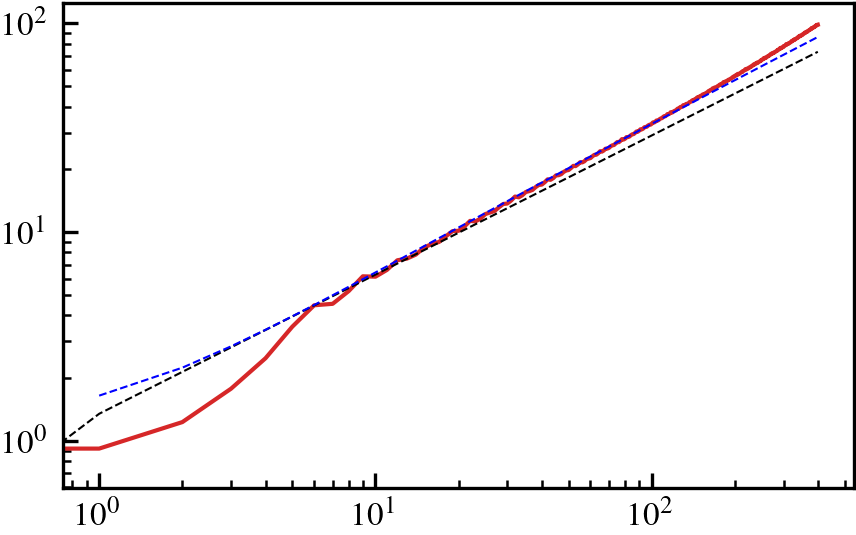

In [85]:
chi = 1200
fig, ax = plt.subplots(1)
seldf_fes = df_fes[df_fes['chi'] == chi]
xvals = np.arange(len(seldf_fes['electron_corr'].values[0]))
yvals = np.abs(obs.denoise_rolling(np.abs(seldf_fes['electron_corr'].values[0]), 4))
logyvals = -(np.log(yvals))
fitwin = [10, 100]
fs = slice(*fitwin)
p, cov = np.polyfit(np.log(xvals[fs]), np.log(logyvals[fs]), 1, cov=True)
m, c = p

m23, c23 = 2./3, 0.3
m1, c1 = 1.0, 0.0
ax.plot(xvals, logyvals, c='C3', alpha=1) 
# axin1.plot(xvals, np.exp(m * np.log(xvals) + c), ls='--', c='k', alpha=1, label=rf'$\!\!\sim\!\!\exp\!|x|^{{{m:.3f}}}$')
ax.plot(xvals, np.exp(m23 * np.log(xvals) + c23), ls='--', c='k', alpha=1, label=r'$\!\!\sim\!\!\exp\!|x|^{\frac{2}{3}}$', lw=0.5)
# ax.plot(xvals, np.exp(m1 * np.log(xvals) + c1), ls='--', c='k', alpha=1, label=r'$\!\!\sim\!\!\exp\!|x|$', lw=0.5)
logN = 0
ml, cl = 2./3, 0.5
wlcorr = np.exp(ml * np.log(xvals) + cl) - (0.25*(Kc+1./Kc)) * np.log(xvals)  - logN
ax.plot(xvals, wlcorr, ls='--', c='b', alpha=1, label=r'$\!\!\sim\!\!\exp\!|x|^{\frac{2}{3}}$', lw=0.5)
ax.set_xscale('log')
ax.set_yscale('log')

N, C, beta, alpha = fit_function(yvals[10:], xvals[10:])
print(N, C, beta, alpha)
print(2./3, 0.25 * (Kc + 1./Kc), Kc)
y_fit = N * xvals**(-beta) * np.exp(-C * xvals**alpha)
# ax.plot(xvals, -np.log(y_fit), ls='--', c='orange')